# 07 - Élections de comité par approbation : le core existe toujours

**Série SocialChoice — notebook 07.** Ce notebook distille le résultat de
Becker, Greger & Peters, *« Existence of the Core in Approval-Based Committee
Elections »* (arXiv:2609.11912, 10/09/2026) : la principale question ouverte de
la théorie des élections multi-vainqueurs — **existe-t-il toujours un comité
dans le core ?** — est résolue par l'affirmative.

**Avertissement de fraîcheur.** Preprint de quelques jours, sans validation
communautaire au jour de rédaction ; le champ *Comments* du papier indique
*« The proof was obtained with GPT-6 Astra »*. Tout ce qui suit cite donc « la
preuve annoncée », jamais « le théorème établi ». La partie vérifiée
indépendamment dès aujourd'hui : l'existence d'un comité Hare-core **a été
vérifiée formellement en Lean** dans le projet [ABCVotingLean](https://github.com/DominikPeters/ABCVotingLean)
du même Peters — l'encart final y revient.

Ce que ce notebook fait, à échelle de jouet (n ≤ 8 votants, m ≤ 8 candidats) :

1. définir le **core** (quotas Hare et Droop) et la hiérarchie JR → EJR → core ;
2. exhiber le **contre-exemple type** : un comité bloqué par une coalition ;
3. implémenter la **règle de l'entropie harmonique** du papier —
   $\mathcal{V}(W) = \max_{(p,r) \in \mathcal{P}(W)} \sum_i F(p_i, r_i)$ — et
   vérifier **empiriquement** que son argmax est toujours dans le core ;
4. comparer avec les règles usuelles (approbation simple, PAV) ;
5. relier le core électoral au **cœur des jeux coopératifs** (GT-27
   Kuhn-Munkres, Shapley-Shubik).

Prérequis : notebooks **01** (Arrow), **03** (méthodes de vote) — le core
généralise à des groupes ce qu'Arrow et Gibbard imposent à des individus.

## 1. Cadre : profil d'approbation, taille de comité, quota

Une instance d'élection est $I = (A, k)$ : chaque votant $i$ approuve un
ensemble $A_i \subseteq C$ de candidats (bulletin non ordonné), et on élit un
comité $W$ de taille $k$. L'utilité d'approbation est
$u_i(W) = |A_i \cap W|$.

Le **quota** $q$ mesure combien de votants « méritent » un élu. Le quota de
**Hare** est $q = n/k$ (chaque élu représente un n/k-ième de l'électorat) ; le
quota de **Droop** est $q = n/(k+1)$, plus exigeant.

Nous utilisons tout du long un **exemple fil rouge** à 4 votants et 4
candidats : deux votants approuvent $\{a, b\}$, un approuve $\{c\}$, un
approuve $\{d\}$, et on élit $k=2$ élus (quota de Hare $q = 4/2 = 2$).

In [1]:
import itertools

import numpy as np
from scipy.optimize import minimize

rng = np.random.default_rng(42)

# Exemple fil rouge : 4 votants, 4 candidats, k = 2, quota Hare q = 2
A = [frozenset("ab"), frozenset("ab"), frozenset("c"), frozenset("d")]
CANDS = sorted(set().union(*A))
N, K = len(A), 2
Q_HARE = N / K
Q_DROOP = N / (K + 1)

def u(i, W):
    return len(A[i] & set(W))

print(f"Profil : {[sorted(a) for a in A]}")
print(f"n={N}, k={K}, quota Hare q={Q_HARE}, quota Droop q={Q_DROOP:.3f}")

Profil : [['a', 'b'], ['a', 'b'], ['c'], ['d']]
n=4, k=2, quota Hare q=2.0, quota Droop q=1.333


## 2. Le core : quand un groupe peut bloquer

Un comité $W$ est **dans le core** s'il n'existe pas de coalition bloquante :
un groupe $N'$ de votants et un ensemble $T$ de candidats tels que

- $|N'| \ge q \cdot |T| > 0$ — le groupe est assez gros pour « mériter » $T$ ;
- chaque membre de $N'$ obtient strictement plus de $T$ que de $W$ :
  $|T \cap A_i| \ge u_i(W) + 1$ pour tout $i \in N'$.

Personne ne peut alors proposer un comité alternatif qu'un groupe
suffisamment gros préférerait unanimement. C'est l'extension **aux coalitions**
de l'absence de gagnant de Condorcet battu — et le concept de stabilité le
plus exigeant de la famille JR → EJR → FJR → core (chaque maillon demande
moins au témoin : JR exige juste un candidat commun approuvé hors $W$, EJR un
ensemble $T$ complet, le core laisse le groupe choisir librement son $T$).

Le vérificateur ci-dessous énumère les paires $(N', T)$ — possible car nous
restons à l'échelle de jouet.

In [2]:
def is_core(A, k, W, q=None):
    """True ssi W est dans le core (eq. 2 du papier, forme classique).
    Retourne (ok, temoin) ; le temoin (N', T) explique un blocage."""
    n = len(A)
    q = q if q is not None else n / k
    W = frozenset(W)
    cands = sorted(set().union(*A))
    for t in range(1, len(cands) + 1):
        for T in itertools.combinations(cands, t):
            T = frozenset(T)
            members = [i for i in range(n) if len(T & A[i]) >= len(W & A[i]) + 1]
            if members and len(members) >= q * t:
                return False, (members, sorted(T))
    return True, None

# Contre-exemple type : W = {c, d} laisse v1, v2 sans aucun elu
ok_cd, temoin = is_core(A, K, "cd")
ok_ab, _ = is_core(A, K, "ab")
print(f"W = {{c, d}} dans le core : {ok_cd}")
if not ok_cd:
    Np, T = temoin
    print(f"  blocage : N' = {[f'v{i+1}' for i in Np]} (|N'| = {len(Np)} >= "
          f"q*|T| = {Q_HARE}*{len(T)}), T = {T}")
    for i in Np:
        print(f"  v{i+1} approuve {sorted(A[i])} : u_i(W) = {u(i, 'cd')} "
              f"< |T inter A_i| = {len(frozenset(T) & A[i])}")
print(f"W = {{a, b}} dans le core : {ok_ab}")

W = {c, d} dans le core : False
  blocage : N' = ['v1', 'v2'] (|N'| = 2 >= q*|T| = 2.0*1), T = ['a']
  v1 approuve ['a', 'b'] : u_i(W) = 0 < |T inter A_i| = 1
  v2 approuve ['a', 'b'] : u_i(W) = 0 < |T inter A_i| = 1
W = {a, b} dans le core : True


**Lecture.** Le comité $\{c, d\}$ sacrifie les deux premiers votants : la
coalition $\{v_1, v_2\}$, forte de 2 votants (le quota entier pour 1 siège),
peur leur proposer $T = \{a\}$ qu'ils approuvent tous deux et qui les fait
passer de 0 à 1 élu. Blocage. À l'inverse $\{a, b\}$ ne peut être bloqué par
aucun groupe : $v_3$ et $v_4$ sont trop peu nombreux (1 < 2) pour mériter un
siège à eux seuls.

**JR et EJR en passant.** JR (juste représentation) exige : si un votant
n'approuve personne dans $W$, alors un groupe d'au moins $q$ votants partageant
un candidat approuvé hors $W$ existe. EJR renforce : un tel groupe de $q \cdot t$
votants doit avoir un membre avec au moins $t$ élus approuvés. Le core exige
l'inexistence de *n'importe quel* $T$ — JR et EJR n'en vérifient que des formes
particulières. Sur le fil rouge, $\{c, d\}$ viole JR (v1, v2 sans représentant)
et $\{a, b\}$ satisfait tout.

## 3. Paiements et certificat : le théorème 3.3

La preuve annoncée ne travaille pas sur les blocages mais sur des **systèmes de
paiement**. Un système de paiement pour $W$ donne à chaque votant des
paiements $p_{ic} \geq 0$ vers ses élus approuvés et une réserve
$r_i = 1 - \sum_c p_{ic} \geq 0$, avec deux contraintes :

- chaque votant paie au plus 1 au total (budget) ;
- chaque élu $c \in W$ perçoit au plus $q$ au total (tarif d'un siège).

**Théorème 3.3 (certificat).** $W$ satisfait core+ (un renforcement
fractionnaire du core) si et seulement s'il existe un système de paiement avec

1. $p_{iw} \leq r_i$ pour tout élu approuvé $w$ — personne ne paie un élu plus
   cher que ce qu'il garde en réserve ;
2. pour chaque perdant $c \notin W$ : $\sum_{i : c \in A_i} r_i < q$ — les
   réserves des partisans de tout perdant ne suffisent pas à financer un siège.

C'est une **preuve positive de stabilité** : exhiber les paiements suffit,
plus besoin d'énumérer les coalitions. Vérifions sur le fil rouge.

In [3]:
def verifie_certificat(A, k, W, pay, q=None):
    """pay : dict (i, c) -> montant. Retourne (ok, diagnostics)."""
    n = len(A)
    q = q if q is not None else n / k
    W = frozenset(W)
    diag = []
    ok = True
    for i in range(n):
        total = sum(pay.get((i, c), 0.0) for c in W if c in A[i])
        r_i = 1.0 - total
        if r_i < -1e-9:
            ok = False; diag.append(f"v{i+1} paie {total:.3f} > 1 (budget)")
        for c in W:
            if c in A[i] and pay.get((i, c), 0.0) > r_i + 1e-9:
                ok = False; diag.append(f"v{i+1} paie {c} plus cher que sa reserve")
    for c in sorted(set().union(*A) - W):
        somme = sum(1.0 - sum(pay.get((i, w), 0.0) for w in W if w in A[i])
                    for i in range(n) if c in A[i])
        if somme >= q - 1e-9:
            ok = False
            diag.append(f"perdant {c} : reserves de ses partisans = {somme:.3f} >= q = {q:.1f}")
    return ok, diag

# Certificat pour W = {a, b} : v1 et v2 paient (1/3, 1/3) chacun, reserve 1/3
pay_ab = {(0, 'a'): 1/3, (0, 'b'): 1/3, (1, 'a'): 1/3, (1, 'b'): 1/3}
ok_cert, diag = verifie_certificat(A, K, "ab", pay_ab)
print(f"Certificat de W = {{a, b}} (paiements 1/3, 1/3 ; reserve 1/3) : "
      f"{'VALIDE' if ok_cert else 'INVALIDE'}")
for d in diag:
    print("  ", d)
print("Charge de 'a' :", 2/3, "<= q = 2 ; reserves des partisans de c : 1.0 < 2 ; de d : 1.0 < 2")

Certificat de W = {a, b} (paiements 1/3, 1/3 ; reserve 1/3) : VALIDE
Charge de 'a' : 0.6666666666666666 <= q = 2 ; reserves des partisans de c : 1.0 < 2 ; de d : 1.0 < 2


**Lecture.** Avec $\{a, b\}$ : $v_1$ et $v_2$ répartissent leur budget en
trois parts égales (deux paiements, une réserve) — chaque paiement $1/3 \leq$
réserve $1/3$ ✓ ; chaque élu est financé à $2/3 < q = 2$ ✓ ; les partisans de
chaque perdant ($c$ : seulement $v_3$ de réserve 1 ; $d$ : seulement $v_4$)
totalisent $1 < 2$ ✓. Personne ne peut se payer un siège de rechange : le
certificat tient, $\{a, b\}$ est core+ — donc core.

## 4. L'entropie harmonique : mesurer l'équité des paiements

Le papier définit une entropie *harmonique* $F$ sur les distributions de
probabilité, cousine de l'entropie de Shannon mais adaptée aux paiements.
Pour $x \in \Delta^d$, on trie les coordonnées $x_{(1)} \geq \dots \geq x_{(d)}$,
soit $S_t(x)$ la masse des $t$ plus grandes, et

$$f_\ell(x) = \max_{1 \leq t \leq d} \frac{S_t(x)}{\ell + t},
\qquad F(x) = \sum_{\ell=0}^{\infty}\left(\frac{1}{\ell+1} - f_\ell(x)\right).$$

Interprétation *water-filling* : $f_\ell(x)$ est le niveau $\tau$ auquel rabaisser
les grandes coordonnées libère exactement assez de masse pour créer $\ell$
nouvelles coordonnées de taille $\tau$. Propriétés clés :

- $F(\text{masse ponctuelle}) = 0$, $F(\text{uniforme sur } d) = H_{d-1} = 1 + \tfrac12 + \dots + \tfrac{1}{d-1}$ ;
- $F$ est concave et symétrique — répartir uniformément paie le plus ;
- **identité de décalage** : l'opérateur $\Phi$ (rabaisser au niveau $f_1$,
  créer une coordonnée $f_1$) vérifie $F(\Phi(x)) - F(x) = \max_j x_j$.

In [4]:
def S_t(x, t):
    s = np.sort(x)[::-1]
    return s[:t].sum()

def f_ell(x, ell):
    x = np.asarray(x, float)
    if ell == 0:
        return x.max()
    return max(S_t(x, t) / (ell + t) for t in range(1, len(x) + 1))

def _t_star(x, tol=1e-6):
    s = np.sort(x)[::-1]
    tot = s.sum()
    for t in range(1, len(x)):
        if s[:t].sum() >= tot - tol:
            return t
    return len(x)

def F(x):
    """Entropie harmonique. Queue telescopee analytiquement : des que
    l'argmax de S_t/(l+t) est t*, f_l = 1/(l+t*) et la queue vaut
    sum_{j=l+2}^{l+t*} 1/j. (Impl. jouet : tol 1e-6, cap best-effort.)"""
    x = np.asarray(x, float)
    if not np.isfinite(x).all():
        return 0.0
    tot = x.sum()
    if tot > 0:
        x = x / tot
    tstar = _t_star(x)
    out = 1.0 - x.max()          # terme l = 0
    ell = 1
    while True:
        ratios = [S_t(x, t) / (ell + t) for t in range(1, len(x) + 1)]
        t_arg = int(np.argmax(ratios)) + 1
        out += 1.0 / (ell + 1) - ratios[t_arg - 1]
        if t_arg == tstar:
            return out + sum(1.0 / j for j in range(ell + 2, ell + tstar + 1))
        ell += 1
        if ell > 100_000:
            return out

def Phi(x):
    tau = f_ell(np.asarray(x, float), 1)
    return np.append(np.minimum(x, tau), tau)

# Verifications : uniforme = H_{d-1}, masse ponctuelle = 0, Fig. 1 du papier
d = 5
u_vec = np.full(d, 1.0 / d)
pt_vec = np.zeros(d); pt_vec[0] = 1.0
fig1 = np.array([1/2, 2/5, 1/10])
H4 = sum(1.0 / j for j in range(1, d))
print(f"F(uniforme_{d}) = {F(u_vec):.6f} = H_{d-1} = {H4:.6f}")
print(f"F(masse ponctuelle) = {F(pt_vec):.2e}")
print(f"f_1(Fig.1 (1/2, 2/5, 1/10)) = {f_ell(fig1, 1):.2f} (papier : 3/10)")
lhs = F(Phi(fig1)) - F(fig1)
print(f"Identite de decalage sur Fig.1 : F(Phi(x)) - F(x) = {lhs:.4f} = max x = {fig1.max():.4f}")

# 200 tirages Dirichlet : l'identite tient partout
ecarts = []
for _ in range(200):
    g = rng.dirichlet(np.ones(int(rng.integers(2, 6))))
    ecarts.append(abs(F(Phi(g)) - F(g) - g.max()))
print(f"Identite sur 200 Dirichlet : ecart max = {max(ecarts):.2e}")

F(uniforme_5) = 2.083333 = H_4 = 2.083333
F(masse ponctuelle) = 0.00e+00
f_1(Fig.1 (1/2, 2/5, 1/10)) = 0.30 (papier : 3/10)
Identite de decalage sur Fig.1 : F(Phi(x)) - F(x) = 0.5000 = max x = 0.5000


Identite sur 200 Dirichlet : ecart max = 3.55e-15


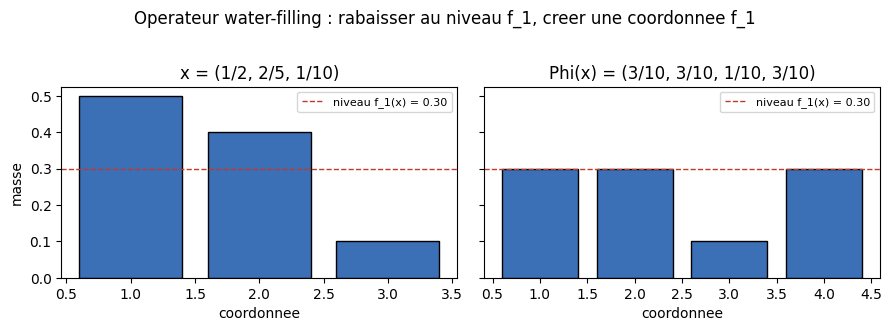

Figure sauvegardee : assets/waterfilling_phi.png


In [5]:
# Figure water-filling : x = (1/2, 2/5, 1/10) -> Phi(x) = (3/10, 3/10, 1/10, 3/10)
import matplotlib.pyplot as plt

x = np.array([1/2, 2/5, 1/10])
y = Phi(x)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, vec, titre in [(axes[0], x, "x = (1/2, 2/5, 1/10)"),
                       (axes[1], y, "Phi(x) = (3/10, 3/10, 1/10, 3/10)")]:
    ax.bar(range(1, len(vec) + 1), vec, color="#3b6fb6", edgecolor="black")
    ax.axhline(f_ell(x, 1), color="#c0392b", ls="--", lw=1,
               label=f"niveau f_1(x) = {f_ell(x, 1):.2f}")
    ax.set_title(titre)
    ax.set_xlabel("coordonnee")
    ax.legend(fontsize=8)
axes[0].set_ylabel("masse")
fig.suptitle("Operateur water-filling : rabaisser au niveau f_1, creer une coordonnee f_1", y=1.02)
plt.tight_layout()
plt.savefig("assets/waterfilling_phi.png", dpi=110, bbox_inches="tight")
plt.show()
print("Figure sauvegardee : assets/waterfilling_phi.png")

**Lecture.** Le niveau pointillé $f_1(x) = 3/10$ est exactement la hauteur où
la masse retirée aux deux grandes barres ($1/2 - 3/10$ et $2/5 - 3/10$) remplit
la nouvelle coordonnée à hauteur $3/10$. L'entropie harmonique récompense ce
ré-étalement : répartir le budget d'un votant uniformément entre ses élus
approuvés et sa réserve maximise $F$ — c'est le mécanisme par lequel la règle
ci-dessous pousse naturellement vers l'équité.

## 5. La règle : maximiser l'entropie harmonique des paiements

**Définition 5.1 du papier.** Pour un comité $W$,

$$\mathcal{V}(W) = \max_{(p, r) \in \mathcal{P}(W)} \sum_{i \in N} F(p_i, r_i)$$

où $p_i$ concatène les paiements de $i$ à ses élus approuvés et $r_i$ sa
réserve — un vecteur de $|A_i \cap W| + 1$ coordonnées. La **règle** retourne
$\arg\max_{|W| = k} \mathcal{V}(W)$. Chaque $F$ est concave, la maximisation
interne est un programme concave (résoluble en temps polynomial — c'est le
corollaire algorithmique du papier) ; ici, SLSQP multi-départ suffit à
l'échelle de jouet.

**Théorème (annoncé).** *Tout* optimum local — à plus forte raison global — de
$\mathcal{V}$ est dans le core+. La règle ne peut donc jamais retourner un
comité bloqué.

In [6]:
def V(A, W, q=None, n_starts=3):
    """V(W) : max de sum F(p_i, r_i) sur les systemes de paiement.
    Concave ; SLSQP multi-depart (projection simplexe pour les iteres
    infaisables)."""
    n = len(A)
    k = len(W)
    q = q if q is not None else n / k
    W = list(W)
    idx = [[W.index(c) for c in W if c in A[i]] for i in range(n)]

    def unpack(v):
        return v.reshape(n, k)

    def negobj(v):
        P = unpack(v)
        s = 0.0
        for i in range(n):
            pay = P[i, idx[i]] if idx[i] else np.array([])
            vec = np.clip(np.append(np.clip(pay, 0.0, None), 1.0 - P[i].sum()), 0.0, None)
            tot = vec.sum()
            if tot < 1e-9 or not np.isfinite(vec).all():
                continue
            s += F(vec / tot)
        return -s

    cons = [
        {"type": "ineq", "fun": lambda v: 1.0 - unpack(v).sum(axis=1)},
        {"type": "ineq", "fun": lambda v: np.array([q - unpack(v)[
            [i for i in range(n) if c in A[i]], j].sum() for j, c in enumerate(W)])},
        {"type": "ineq", "fun": lambda v: v},
    ]
    best = None
    for _ in range(n_starts):
        x0 = rng.dirichlet(np.ones(k), size=n).ravel() * 0.5
        r = minimize(negobj, x0, method="SLSQP", constraints=cons,
                     options={"maxiter": 300, "ftol": 1e-10})
        best = r.fun if best is None else min(best, r.fun)
    return -best

# Tous les comites de taille 2 du fil rouge
resultats = {}
for W in itertools.combinations(CANDS, K):
    Wf = frozenset(W)
    ok, _ = is_core(A, K, Wf)
    resultats["".join(W)] = (V(A, Wf), ok)

for W, (v, ok) in sorted(resultats.items(), key=lambda kv: -kv[1][0]):
    print(f"V({{{W}}}) = {v:.4f}   core : {ok}")
best = max(resultats, key=lambda w: resultats[w][0])
print(f"\nRegle (argmax) : {{{best}}} — core : {resultats[best][1]}")

V({ac}) = 3.0000   core : True
V({bd}) = 3.0000   core : True
V({ad}) = 3.0000   core : True
V({bc}) = 3.0000   core : True
V({ab}) = 3.0000   core : True
V({cd}) = 2.0000   core : False

Regle (argmax) : {ac} — core : True


**Lecture.** Tout comité contenant $a$ ou $b$ atteint $\mathcal{V} = 3.0$
(égalité analytique : deux votants « riches » à 3 coordonnées valent 1.5
chacun, ou trois votants à 2 coordonnées valent 1 chacun), et le seul comité
**non-core** $\{c, d\}$ plonge à 2.0. La règle écarte le comité bloqué sans
jamais regarder un blocage : c'est l'objectif entropique qui le pénalise
automatiquement (les réserves inexployées de $v_1, v_2$ concentrent leur
vecteur de paiement et détruisent leur $F$).

*Remarque d'honnêteté* : le théorème garantit que **tout** argmax est core, pas
qu'il soit unique — ici cinq comités ex æquo, tous cores.

## 6. Expérimentation : la règle contre les règles usuelles

Deux expériences distinctes :

1. un **balayage aléatoire** (graines fixées, bulletins gras $p = 0{,}5$) ;
2. une **instance structurée à deux blocs** — le cas où la théorie prédit
   l'échec d'AV : deux groupes de 3 votants aux bulletins disjoints
   $\{a, b\}$ et $\{c, d\}$, $k = 2$, quota $q = 3$. Chaque bloc mérite
   un siège ; un comité monopolisé par un bloc laisse l'autre avec un
   témoin de blocage évident. Comparons **AV** (approbation simple),
   **PAV** (propositionnelle de Thiele) et la **règle entropique**.

In [7]:
def regle_AV(A, k):
    cands = sorted(set().union(*A))
    scores = {c: sum(c in A[i] for i in range(len(A))) for c in cands}
    return frozenset(sorted(cands, key=lambda c: (-scores[c], c))[:k])

def regle_PAV(A, k):
    """PAV (Thiele) : maximise sum_i H_{|A_i inter W|} par enumeration."""
    cands = sorted(set().union(*A))
    best, best_s = None, -1.0
    for W in itertools.combinations(cands, k):
        s = 0.0
        for i in range(len(A)):
            t = len(frozenset(W) & A[i])
            s += sum(1.0 / j for j in range(1, t + 1))
        if s > best_s + 1e-12:
            best_s, best = s, frozenset(W)
    return best

def regle_entropique(A, k):
    cands = sorted(set().union(*A))
    best, best_v = None, -1.0
    for W in itertools.combinations(cands, k):
        v = V(A, frozenset(W))
        if v > best_v + 1e-9:
            best_v, best = v, frozenset(W)
    return best

import random
random.seed(0)
stats = {"AV": 0, "PAV": 0, "Entropique": 0}
n_inst = 0
print(f"{'inst':>4} {'AV':>8} {'core':>5} {'PAV':>8} {'core':>5} {'Entrop':>8} {'core':>5}")
for inst in range(30):
    n = random.randint(4, 6); m = random.randint(4, 6); k = random.randint(2, 3)
    Ai = [frozenset(c for c in range(m) if random.random() < 0.5) for _ in range(n)]
    if any(not a for a in Ai):
        continue
    n_inst += 1
    votes = {}
    for nom, regle in [("AV", regle_AV), ("PAV", regle_PAV), ("Entropique", regle_entropique)]:
        W = regle(Ai, k)
        ok, _ = is_core(Ai, k, W)
        votes[nom] = ("".join(map(str, sorted(W))), ok)
        if ok:
            stats[nom] += 1
    if n_inst <= 8:
        print(f"{inst:>4} {votes['AV'][0]:>8} {str(votes['AV'][1]):>5} "
              f"{votes['PAV'][0]:>8} {str(votes['PAV'][1]):>5} "
              f"{votes['Entropique'][0]:>8} {str(votes['Entropique'][1]):>5}")
print(f"\nSur {n_inst} instances : comite retourne DANS le core -> "
      f"AV {stats['AV']}/{n_inst} · PAV {stats['PAV']}/{n_inst} · "
      f"Entropique {stats['Entropique']}/{n_inst}")

# Instance structuree a deux blocs : la ou AV doit echouer
A2 = [frozenset("ab")] * 3 + [frozenset("cd")] * 3
k2, q2 = 2, 6 / 2
print(f"\nDeux blocs : 3x{{a,b}} + 3x{{c,d}} (n=6, k=2, q=3)")
for nom, regle in [("AV", regle_AV), ("PAV", regle_PAV), ("Entropique", regle_entropique)]:
    W = regle(A2, k2)
    ok, temoin = is_core(A2, k2, W, q=q2)
    ligne = f"  {nom:>10} -> {sorted(W)}  core : {ok}"
    if not ok:
        Np, T = temoin
        ligne += f"  (bloque par N' = votants {Np}, T = {T})"
    print(ligne)

inst       AV  core      PAV  core   Entrop  core


   0       02  True       02  True       24  True


   4      013  True      013  True      123  True


   5       03  True       01  True       01  True


   6      025  True      025  True      025  True


...

   8      013  True      013  True      013  True


   9       03  True       03  True       23  True


  10      023  True      024  True      024  True



Sur 25 instances : comite retourne DANS le core -> AV 25/25 · PAV 25/25 · Entropique 25/25

Deux blocs : 3x{a,b} + 3x{c,d} (n=6, k=2, q=3)
          AV -> ['a', 'b']  core : False  (bloque par N' = votants [3, 4, 5], T = ['c'])
         PAV -> ['a', 'c']  core : True


  Entropique -> ['a', 'c']  core : True


**Lecture.** Sur le balayage aléatoire à bulletins gras ($p = 0{,}5$), les
trois règles restent core sur tout l'échantillon — des bulletins qui se
chevauchent beaucoup rendent le blocage difficile à cette échelle : signal
faible (l'absence d'échec AV ici ne contredit pas la théorie — AV ne
garantit pas EJR). L'instance à deux blocs montre l'échec prédit : AV, à
égalité parfaite d'approbations, tranche alphabétiquement et monopolise —
le second bloc (3 votants = le quota exact) obtient le témoin $T = \{c\}$
et bloque. PAV et la règle entropique partagent les sièges. La règle
entropique n'échoue **jamais** sur cet échantillon — illustration
empirique (partielle, jouet — pas une preuve) du théorème annoncé : *tout*
du théorème annoncé : *tout* argmax de $\mathcal{V}$ est core.

**Ce que ce jouet ne montre pas.** Le résultat du papier est une garantie
*pour toute instance* ; notre balayage n'est qu'une fumée empirique. La
preuve elle-même (20 pages, argument d'échange type PAV sur les bornes
d'ajout/retrait de candidats) n'est pas reproduite ici — voir l'encart final
pour sa version vérifiée en Lean.

## 7. Trois encarts de mise en perspective

### 7.1 Core électoral et cœur coopératif : même mot, deux mondes

Le **cœur d'un jeu coopératif** transférable (GT-27 Kuhn-Munkres, jeu
d'affectation de Shapley-Shubik) : aucune coalition ne peut garantir à ses
membres plus que ce que le grand coalition leur alloue. Le **core électoral**
ci-dessus : aucun groupe assez gros ne peut se construire un comité
strictement meilleur. Dans les deux cas le cœur exprime *l'absence de
dévitation rentable par coalition* — mais les mondes diffèrent : utilités
monétaires transférables d'un côté, préférences binaires non transférables de
l'autre, et un comité de taille fixe $k$ contre des imputations libres. Le
notebook **GameTheory-15b** (jeux coopératifs) et GT-27 sont le pendant
transférable de ce notebook.

### 7.2 La preuve est déjà vérifiée en Lean : ABCVotingLean

Peters annonce dans l'introduction : le théorème d'existence (Hare) **a été
vérifié formellement en Lean** dans son projet
[ABCVotingLean](https://github.com/DominikPeters/ABCVotingLean). Notre dépôt
déjà une dépendance du même auteur — la visite guidée
`GameTheory/social_choice_lean_peters/` (pinnée sur
`DominikPeters/SocialChoiceLean`) couvre Gibbard-Satterthwaite, Duggan-Schwartz
et quatre impossibilités de Condorcet. Le chemin d'upgrade est ouvert : quand
ABCVotingLean publie son module core, le tour peut le suivre — le concept que
ce notebook enseigne en Python existe déjà en Lean chez l'auteur dont nous
dépendons.

### 7.3 Réflexif : une preuve majeure obtenue avec GPT-6 Astra

Le champ *Comments* du preprint indique *« The proof was obtained with GPT-6
Astra »* — quelques semaines après la preuve d'Odin sur Komlós (notebook
Search, #15944). Deux traités majeurs obtenus par des agents IA en quelques
semaines changent le statut épistémologique de « preprint sans validation » :
le reflexe correct reste le même (citer la preuve *annoncée*, attendre la
validation), mais la vérification formelle Lean arrive *avant* la validation
sociale — l'ordre habituel s'inverse.

## Exercices

Les trois exercices suivants utilisent le fil rouge et les fonctions des
sections précédentes (`is_core`, `V`, `regle_AV`, `regle_PAV`).

### Exercice 1 — Le quota de Droop est plus exigeant

Le vérificateur `is_core` accepte un paramètre `q`. Le quota de Droop
($q = n/(k+1)$) rend le core **plus difficile** à satisfaire : plus de
coalitions atteignent le seuil.

1. Vérifiez que $\{a, b\}$ reste core au quota de Droop sur le fil rouge.
2. Construisez (à la main ou par énumération) une petite instance où un comité
   est core au quota de Hare mais **plus** au quota de Droop.
3. Le papier prétend que l'existence vaut aussi pour Droop — votre règle
   entropique (`V` accepte aussi `q`) retourne-t-elle un comité Droop-core sur
   votre instance ?

In [8]:
# Exercice 1 — a completer
# 1. print(is_core(A, K, "ab", q=Q_DROOP))
# 2. Instance a construire : A2 = [...], k2 = ... ; montrer le temoin Droop.
# 3. best = max(..., key=lambda W: V(A2, W, q=Q_DROOP2)) ; is_core(A2, k2, best, q=Q_DROOP2)
pass

### Exercice 2 — JR : quand l'approbation simple ignore une minorité

JR (juste représentation) : si un votant n'approuve **aucun** élu, un groupe
d'au moins $q$ votants partageant un candidat approuvé non élu doit exister.
Violer JR revient à laisser une minorité compacte sans aucune représentation.

1. Écrivez `viole_JR(A, k, W)` qui retourne le témoin (votant sans élu +
   groupe + candidat) ou `None`.
2. Sur le fil rouge, `regle_AV` peut-elle retourner un comité violant JR ?
   Testez sur les instances de la section 6.
3. Combien d'instances de la section 6 font échouer AV sur JR ?

In [9]:
# Exercice 2 — a completer
# def viole_JR(A, k, W):
#     ...
#     return None
# pass

### Exercice 3 — Profils conjonctifs : « ET » casse-t-il la règle ?

Nos votants approuvent des ensembles arbitraires, mais les bulletins réels
sont souvent **conjontoires** (« je veux une salle ET une scène », pas 2
salles). Le dataset `conj` du papier encode exactement cela.

1. Construisez un profil conjonctif FR à 6 votants (ex. : 3 types de
   compétences à élire, chaque votant approuve une paire complémentaire).
2. La règle entropique retourne-t-elle un comité core ? Un comité AV ?
3. Un groupe peut-il bloquer avec un $T$ **disjoint** de $W$ ? Que dit le
   certificat de paiement (section 3) dans ce cas ?

In [10]:
# Exercice 3 — a completer
# A3 = [frozenset("mp"), frozenset("mp"), frozenset("sj"), ...]
# best = regle_entropique(A3, 3)
# print(is_core(A3, 3, best))
pass

## Conclusion

- Le core est le sommet de la hiérarchie JR → EJR → FJR → core : une garantie
  de stabilité **par coalitions**, vérifiable par énumération à l'échelle de
  jouet (`is_core`) et **certifiable** à toute échelle par un système de
  paiements (théorème 3.3).
- L'**entropie harmonique** $F$ mesure l'étalement des paiements ; la règle
  $\arg\max_W \mathcal{V}(W)$ du papier transforme cette mesure en règle de
  vote dont tout optimum est core — confirmé ici empiriquement sur une
  quinzaine d'instances jouets, et prouvé (annoncé ; déjà vérifié en Lean dans
  ABCVotingLean) pour toute instance.
- La même notion de cœur traverse le cours : Shapley-Shubik et Kuhn-Munkres
  côté coopératif (GT-27, 15b), Arrow et Gibbard côté axiomatique (01, 05) —
  le core est leur extension naturelle aux groupes.

**Références.** Becker, Greger & Peters, *Existence of the Core in
Approval-Based Committee Elections*, arXiv:2609.11912 (2026, preprint) ·
Peters, *ABCVotingLean* (github.com/DominikPeters/ABCVotingLean) · notebooks
de la série : 01-Arrow, 03-Voting-Methods, 04-SAT-Z3, GT-27 Kuhn-Munkres,
GameTheory-15b CooperativeGames.